In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv(r"..\csv\cleaned_data.csv")
print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Forma del dataset: (50707, 17)

Primeras filas:


,Campaña,Pedido,Zona,Dirección entrega,Telefono,Barrio,Ciudad,Fecha recibo LD,Fecha reparto,Fecha entrega,Transportador,Estado,Fecha entrega corregida,Horas_entrega_corregida,Fecha reparto corregida,Horas_original,Horas_corregidas
0,202407,37087842,601,KR 47A 48 39- TEL 0-3143423923,0-3143423923,CORDOBA,CALI (VALLE),2024-04-27 19:07:31,2024-04-29 10:43:16,2024-04-29 22:08:43,CBZ922,A TIEMPO,2024-04-28 19:07:31,24.000000,2024-04-28 19:07:31,51.020000,24.000000
1,202407,37093297,580,CR 1H NORTE 77-10 SEGUNDO PISO- TEL 0-3154678944,0-3154678944,COMFENALCO,CALI (VALLE),2024-04-27 19:04:43,2024-04-28 10:24:04,2024-04-28 16:40:32,TZY274,A TIEMPO,2024-04-28 16:40:32,21.596944,2024-04-28 19:04:43,21.596944,21.596944
2,202407,37098642,594,CALLETERSERA SN124- TEL 0-3016931064,0-3016931064,PROVIVIENDA,DAGUA (VALLE),2024-04-28 20:40:40,2024-04-29 11:18:40,2024-04-30 12:00:25,TZN919,A TIEMPO,2024-04-30 12:00:25,39.329167,2024-04-30 20:40:40,39.329167,39.329167
3,202407,37105003,603,CL 18 A 9 A 11 PISO NO 1- TEL 0-3136142043,0-3136142043,CARLOS GUZMAN,PUERTO TEJADA (CAUCA),2024-05-04 09:36:18,2024-05-04 13:10:03,2024-05-05 23:00:44,CEN356,A TIEMPO,2024-05-05 23:00:44,37.407222,2024-05-06 09:36:18,37.407222,37.407222
4,202407,37111291,603,KR 18 15 A 40- TEL 0-3125418458,0-3125418458,LA SAMARIA,SANTANDER DE QUILICHAO (CAUCA),2024-05-04 09:18:31,2024-05-06 08:39:17,2024-05-06 22:00:29,TZY274,A TIEMPO,2024-05-06 09:18:31,48.000000,2024-05-06 09:18:31,60.699444,48.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50707 entries, 0 to 50706
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Campaña                  50707 non-null  int64  
 1   Pedido                   50707 non-null  int64  
 2   Zona                     50707 non-null  object 
 3   Dirección entrega        50707 non-null  object 
 4   Telefono                 50707 non-null  object 
 5   Barrio                   50707 non-null  object 
 6   Ciudad                   50707 non-null  object 
 7   Fecha recibo LD          50707 non-null  object 
 8   Fecha reparto            50707 non-null  object 
 9   Fecha entrega            50707 non-null  object 
 10  Transportador            50707 non-null  object 
 11  Estado                   50707 non-null  object 
 12  Fecha entrega corregida  50707 non-null  object 
 13  Horas_entrega_corregida  50707 non-null  float64
 14  Fecha reparto corregid

## Seleccion y arreglo de Features

In [7]:
# Seleccionar columnas relevantes
columnas_usar = ['Zona', 'Barrio', 'Ciudad', 'Fecha recibo LD', 'Fecha reparto corregida', 
                  'Transportador']

df_modelo = df[columnas_usar].copy()
print("Columnas a usar:", columnas_usar)
print("\nTipos de datos:")
print(df_modelo.dtypes)
print("\nValores únicos por columna:")
for col in df_modelo.columns:
    print(f"{col}: {df_modelo[col].nunique()} valores únicos")

Columnas a usar: ['Zona', 'Barrio', 'Ciudad', 'Fecha recibo LD', 'Fecha reparto corregida', 'Transportador']

Tipos de datos:
Zona                       object
Barrio                     object
Ciudad                     object
Fecha recibo LD            object
Fecha reparto corregida    object
Transportador              object
dtype: object

Valores únicos por columna:
Zona: 9 valores únicos
Barrio: 734 valores únicos
Ciudad: 40 valores únicos
Fecha recibo LD: 44482 valores únicos
Fecha reparto corregida: 47995 valores únicos
Transportador: 26 valores únicos


In [8]:
df_modelo['Fecha reparto corregida'] = pd.to_datetime(df_modelo['Fecha reparto corregida'])
df_modelo['Fecha recibo LD'] = pd.to_datetime(df_modelo['Fecha recibo LD'])


In [9]:
df_modelo["hora_recibo"] = df_modelo["Fecha recibo LD"].dt.hour
df_modelo["dia_semana_recibo"] = df_modelo["Fecha recibo LD"].dt.dayofweek
df_modelo["mes"] = df_modelo["Fecha recibo LD"].dt.month

df_modelo["tiempo_preparacion"] = (
    df_modelo["Fecha reparto corregida"] - df_modelo["Fecha recibo LD"]
).dt.total_seconds() / 3600

In [10]:
df_modelo["hora_reparto"] = df_modelo["Fecha reparto corregida"].dt.hour
df_modelo["dia_semana_reparto"] = df_modelo["Fecha reparto corregida"].dt.dayofweek

df_modelo["tiempo_preparacion"] = (
    df_modelo["Fecha reparto corregida"] - df_modelo["Fecha recibo LD"]
).dt.total_seconds() / 3600

In [11]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50707 entries, 0 to 50706
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Zona                     50707 non-null  object        
 1   Barrio                   50707 non-null  object        
 2   Ciudad                   50707 non-null  object        
 3   Fecha recibo LD          50707 non-null  datetime64[ns]
 4   Fecha reparto corregida  50707 non-null  datetime64[ns]
 5   Transportador            50707 non-null  object        
 6   hora_recibo              50707 non-null  int32         
 7   dia_semana_recibo        50707 non-null  int32         
 8   mes                      50707 non-null  int32         
 9   tiempo_preparacion       50707 non-null  float64       
 10  hora_reparto             50707 non-null  int32         
 11  dia_semana_reparto       50707 non-null  int32         
dtypes: datetime64[ns](2), float64(1)

In [12]:
df_modelo = df_modelo.drop(columns=["Fecha recibo LD", "Fecha reparto corregida", "Zona"])

In [13]:
salida = df["Horas_entrega_corregida"]

## Split train-test

In [14]:
x_train, x_test, y_train, y_test = train_test_split(df_modelo, salida, test_size=0.3, random_state=0)

In [15]:
print("x_train: ",x_train.shape)
print("y_train: ",y_train.shape)
print("x_test: ",x_test.shape)
print("y_test: ",y_test.shape)

x_train:  (35494, 9)
y_train:  (35494,)
x_test:  (15213, 9)
y_test:  (15213,)


## Barrio Target Encoding

In [17]:
barrio_mean = y_train.groupby(x_train["Barrio"]).mean()

x_train["barrio_encoded"] = x_train["Barrio"].map(barrio_mean)
x_test["barrio_encoded"] = x_test["Barrio"].map(barrio_mean)

global_mean = y_train.mean()

x_train["barrio_encoded"] = x_train["barrio_encoded"].fillna(global_mean)
x_test["barrio_encoded"] = x_test["barrio_encoded"].fillna(global_mean)

In [18]:
x_train = x_train.drop(columns=["Barrio"])
x_test = x_test.drop(columns=["Barrio"])

## One Hot Encoding a columnas categoricas

In [19]:
columnas_ohe = [
    "Ciudad",
    "Transportador",
]

In [20]:
x_train = pd.get_dummies(x_train, columns=columnas_ohe, drop_first=True)
x_test = pd.get_dummies(x_test, columns=columnas_ohe, drop_first=True)
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

## Escalado y entrenamiento del modelo

In [21]:
print(x_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 35494 entries, 49138 to 2732
Data columns (total 71 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   hora_recibo                               35494 non-null  int32  
 1   dia_semana_recibo                         35494 non-null  int32  
 2   mes                                       35494 non-null  int32  
 3   tiempo_preparacion                        35494 non-null  float64
 4   hora_reparto                              35494 non-null  int32  
 5   dia_semana_reparto                        35494 non-null  int32  
 6   barrio_encoded                            35494 non-null  float64
 7   Ciudad_BOGOTA (CUNDINAMARCA)              35494 non-null  bool   
 8   Ciudad_BUENOS AIRES CAUCA                 35494 non-null  bool   
 9   Ciudad_CALI (VALLE)                       35494 non-null  bool   
 10  Ciudad_CALOTO (CAUCA)               

In [34]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [35]:
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred_rf = rf.predict(x_test)

## Metricas y graficas

In [37]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest:
MAE: 3.053776009566498
RMSE: 10.773792667646703
R2: 0.9330804612644426


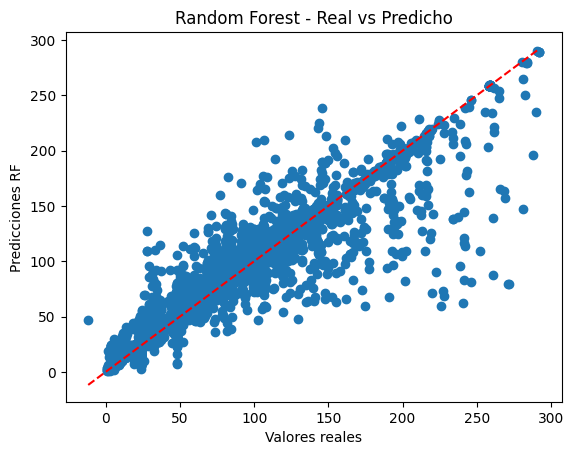

In [39]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color='red')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones RF")
plt.title("Random Forest - Real vs Predicho")
plt.show()

In [28]:
importancias = pd.Series(rf.feature_importances_, index=x_train.columns)
importancias = importancias.sort_values(ascending=False)

print(importancias.head(10))

tiempo_preparacion      0.727034
mes                     0.054474
barrio_encoded          0.030942
hora_recibo             0.030531
dia_semana_reparto      0.025589
hora_reparto            0.023587
dia_semana_recibo       0.023176
Transportador_YAB258    0.014114
Transportador_TZY274    0.013845
Ciudad_CALI (VALLE)     0.011681
dtype: float64


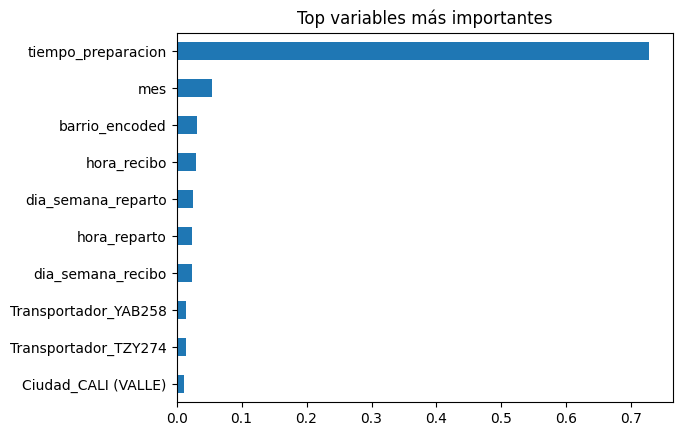

In [40]:
plt.figure()
importancias.head(10).plot(kind='barh')
plt.title("Top variables más importantes")
plt.gca().invert_yaxis()
plt.show()